In [48]:
from SDP_interaction_inference import simulation
from SDP_interaction_inference import optimization
from SDP_interaction_inference import utils
from SDP_interaction_inference import optimization_utils
import matplotlib.pyplot as plt
import numpy as np
import scipy
import tqdm

In [2]:
rng = np.random.default_rng(643)

In [50]:
def compute_feasible_correlation(S, d, y_feas):
    '''Compute correlation value at feasible point.'''
    
    # find indices of moments
    powers = utils.compute_powers(S, d)
    if S == 4:
        i_xy = powers.index([1, 1, 0, 0])
        i_x  = powers.index([1, 0, 0, 0])
        i_y  = powers.index([0, 1, 0, 0])
        i_x2 = powers.index([2, 0, 0, 0])
        i_y2 = powers.index([0, 2, 0, 0])
    elif S == 2:
        i_xy = powers.index([1, 1])
        i_x  = powers.index([1, 0])
        i_y  = powers.index([0, 1])
        i_x2 = powers.index([2, 0])
        i_y2 = powers.index([0, 2])

    # collect moment values
    E_xy = y_feas[i_xy]
    E_x  = y_feas[i_x]
    E_y  = y_feas[i_y]
    E_x2 = y_feas[i_x2]
    E_y2 = y_feas[i_y2]

    # compute statistics
    cov_xy = E_xy - E_x*E_y
    var_x = E_x2 - E_x**2
    var_y = E_y2 - E_y**2

    # return None if correlation undefined
    if var_x <= 0 or var_y <= 0:
        return None

    # compute correlation
    correlation = cov_xy / (np.sqrt(var_x) * np.sqrt(var_y))

    return correlation

In [ ]:
def hit_and_run(OB_bounds, beta, d_bd, d_sd, d_me, feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd, d_me)

    # helpful values
    reactions = [
        "1",
        "xs[0]",
        "1",
        "xs[1]",
        "xs[0] * xs[1]"
    ]
    vrs = [
        [1, 0],
        [-1, 0],
        [0, 1],
        [0, -1],
        [-1, -1]
    ]
    db = 2
    R = 5
    S = 2
    U = []
    Nd = utils.compute_Nd(S, d)
    Nbd = utils.compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = optimization_utils.compute_B(beta, S, U, d_bd)

    # separate feasible points
    y_feas = np.array(feas[:Nbd])
    k_feas = np.array(feas[Nbd:])

    # record feasible points
    y_feas_list = [y_feas]
    k_feas_list = [k_feas]

    # record correlations
    correlations = [compute_feasible_correlation(S, d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # record zero intervals
    t_int_zero = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]
        k_feas = k_feas_list[-1]

        if n % 2:
            #v_y = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
            #v_y = v_y / np.linalg.norm(v_y)
            #v_y[0] = 0

            viy = rng.integers(1, Nd)
            v_y = np.zeros(Nd)
            v_y[viy] = 1

            v_k = np.zeros(R)
        
        else:
            v_y = np.zeros(Nd)

            #v_k = rng.multivariate_normal(np.zeros(R), np.diag(np.ones(R)))
            #v_k = v_k / np.linalg.norm(v_k)

            vik = rng.integers(R)
            v_k = np.zeros(R)
            v_k[vik] = 1


        # sample random direction (uniform on sphere)
        #v = rng.multivariate_normal(np.zeros(Nd + R), np.diag(np.ones(Nd + R)))
        #v = v / np.linalg.norm(v)


        # ignore 1st dimension as fixed y[0] = 1
        #v[0] = 0

        # separate k and v directions
        #v_y = v[:Nbd]
        #v_k = v[Nbd:]

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v_y
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[i, :] = [-np.inf, np.inf]

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # generalized eigenvalues
            C = optimization_utils.compute_M_s_value(y_feas, s, S, d)
            D = optimization_utils.compute_M_s_value(v_y, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # moment equation t values
        t_meq = set()
        moment_powers = utils.compute_powers(S, d_me - db + 1)
        for alpha in moment_powers:

            # compute A as R x N_d, so no need to subset to d_me
            A_alpha_d = optimization_utils.compute_A(alpha, reactions, vrs, db, R, S, d)

            a = v_k.T @ A_alpha_d @ y_feas + k_feas.T @ A_alpha_d @ v_y
            b = v_k.T @ A_alpha_d @ v_y

            # only t = 0 feasible (never happens?)
            if ((a == 0) and (b != 0)) or ((a != 0) and (b == 0)):
                t_min = 0
                t_max = 0
                break
            # one non-zero t feasible
            elif ((a != 0) and (b != 0)):
                t_meq.add(- a / b)
            # otherwise all t feasible (somtimes happens)
            else:
                pass

        # cannot have distinct feasible t values
        if len(t_meq) > 1:
            t_min = 0
            t_max = 0
        # unique feasible t value: must be in linear + SDP interval
        elif len(t_meq) == 1:
            t_meq = t_meq.pop()
            if ((t_meq < t_min) or (t_meq > t_max)):
                t_min = 0
                t_max = 0
            else:
                t_min = t_meq
                t_max = t_meq
        
        # if t interval is [0, 0] skip
        if t_min == 0 and t_max == 0:
            t_int_zero += 1
            continue
        # if t interval is single t move to 'sampling' (use this t)
        elif t_min == t_max:
            pass
        # if width of t interval too small / numerical error: skip
        elif (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v_y
        k_feas_new = k_feas + ts * v_k

        # store
        y_feas_list.append(y_feas_new)
        k_feas_list.append(k_feas_new)
        correlations.append(compute_feasible_correlation(S, d, y_feas_new))

    # collect results
    data = {
        'correlations': correlations,
        'y_feas_list': y_feas_list,
        'k_feas_list': k_feas_list,
        't_int_err': t_int_err,
        't_int_eps': t_int_eps,
        't_int_zero': t_int_zero
    }

    return data

## Running

In [158]:
dataset = simulation.simulate_dataset_range_BD([1])
dataset.bootstrap(d=4)
OB_bounds = dataset.moment_bounds['sample-0']

In [159]:
d = 3
BD_int = optimization.BirthDeathOptimization(dataset, d=d, K=10, fixed=[])
BD_int.analyse_dataset()

100%|██████████| 1/1 [00:00<00:00, 13.17it/s]


In [160]:
S = 2
feas_dict = BD_int.feasible_values_dict[0][-1]
feas = list(feas_dict.values())
BD_int.result_dict

{0: {'status': 'OPTIMAL',
  'time': 0.0019998550415039062,
  'cuts': 0,
  'correlation': np.float64(-0.156181052628756)}}

In [171]:
result = hit_and_run(
    OB_bounds=OB_bounds,
    beta=dataset.beta,
    d_bd=3, d_sd=3, d_me=3,
    feas=feas,
    N=1000,
    eps=10**-6
)

  2%|▏         | 23/999 [00:00<00:08, 109.75it/s]

0.0 1.1413249999999997
-0.5567509684245286 0.584574031575471
-0.4867446281685086 0.6545803718314911


  5%|▍         | 48/999 [00:00<00:08, 115.12it/s]

-0.017848117319287038 1.1234768826807127
0.0 0.8530250000000001
-0.16444540998640367 0.6885795900135965
-0.8969700949924335 0.24435490500756618


  7%|▋         | 73/999 [00:00<00:07, 119.03it/s]

...

 81%|████████  | 810/999 [00:08<00:02, 83.26it/s]

-0.7020855404824804 0.15093945951751975
-0.25434206965424533 0.5986829303457548
-0.5328033869299853 0.32022161307001484


 83%|████████▎ | 833/999 [00:08<00:01, 97.07it/s]

-0.18817372901488216 0.664851270985118
-0.6978905400732032 0.15513445992679697
-0.7665397205309832 0.08648527946901696


KeyboardInterrupt: 

In [162]:
result['t_int_err'], result['t_int_eps'], result['t_int_zero']

(0, 0, 887)

In [166]:
result['y_feas_list']

[array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 1.919975  , 0.48563383, 0.48050235, 2.26995   ]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 1.919975  , 0.48563383, 0.48050235, 3.21388498]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 2.14024495, 0.48563383, 0.48050235, 3.21388498]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 2.14024495, 0.48563383, 0.48050235, 3.05940204]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 2.14024495, 0.48563383, 0.48050235, 3.02590107]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 2.14024495, 0.48563383, 0.48050235, 3.07905971]),
 array([1.        , 0.63622685, 0.67950362, 1.08127931, 0.3217839 ,
        1.20213989, 2.14024495, 0.48563383, 0.48050235, 2.87458685]),
 array([1.        , 0.63622685, 0.

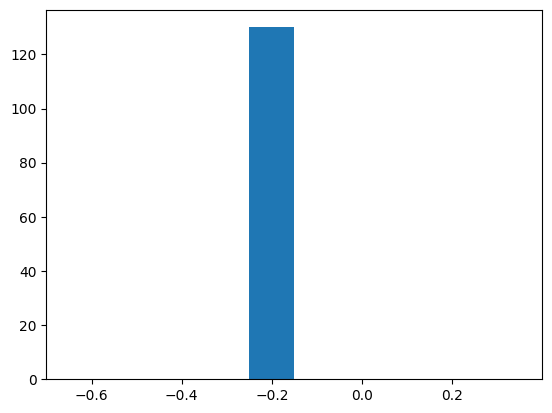

In [163]:
plt.hist(feasible_correlation);